In [1]:
# Data Profiling - Jobs in Data Dataset
# Load raw data from Kaggle and perform initial data profiling

import os
import sys
from pathlib import Path

# ensure project root is on sys.path so `src` is importable from notebook
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.chdir(project_root)

# Clear cached modules to ensure fresh import
for mod in list(sys.modules.keys()):
    if mod.startswith('src'):
        del sys.modules[mod]

import yaml
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load_data import load_raw_data_with_fallback

d:\app\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load configuration
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

print(f"Project: {config['project']['name']}")
print(f"Dataset: {config['data']['dataset']}")

Project: Jobs in Data Analysis
Dataset: hummaamqaasim/jobs-in-data


In [3]:
# Load raw data (downloads from Kaggle if not available locally)
df = load_raw_data_with_fallback(
    raw_dir="../data/raw",
    dataset=config["data"]["dataset"]
)
df.head()

Loaded 9355 rows, 12 columns


,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
0,2023,Data DevOps Engineer,Data Engineering,EUR,88000,95012,Germany,Mid-level,Full-time,Hybrid,Germany,L
1,2023,Data Architect,Data Architecture and Modeling,USD,186000,186000,United States,Senior,Full-time,In-person,United States,M
2,2023,Data Architect,Data Architecture and Modeling,USD,81800,81800,United States,Senior,Full-time,In-person,United States,M
3,2023,Data Scientist,Data Science and Research,USD,212000,212000,United States,Senior,Full-time,In-person,United States,M
4,2023,Data Scientist,Data Science and Research,USD,93300,93300,United States,Senior,Full-time,In-person,United States,M


## 1. Basic Information

In [4]:
# Dataset shape
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn names:\n{df.columns.tolist()}")

Rows: 9,355
Columns: 12

Column names:
['work_year', 'job_title', 'job_category', 'salary_currency', 'salary', 'salary_in_usd', 'employee_residence', 'experience_level', 'employment_type', 'work_setting', 'company_location', 'company_size']


In [5]:
# Data types and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9355 entries, 0 to 9354
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           9355 non-null   int64 
 1   job_title           9355 non-null   object
 2   job_category        9355 non-null   object
 3   salary_currency     9355 non-null   object
 4   salary              9355 non-null   int64 
 5   salary_in_usd       9355 non-null   int64 
 6   employee_residence  9355 non-null   object
 7   experience_level    9355 non-null   object
 8   employment_type     9355 non-null   object
 9   work_setting        9355 non-null   object
 10  company_location    9355 non-null   object
 11  company_size        9355 non-null   object
dtypes: int64(3), object(9)
memory usage: 877.2+ KB


#### Schema of data sources:
![data source schema](..\resources\Untitled.png)

## 2. Statistical Summary

In [6]:
# Numerical columns statistics
df.describe()

,work_year,salary,salary_in_usd
count,9355.000000,9355.000000,9355.000000
mean,2022.760449,149927.981293,150299.495564
std,0.519470,63608.835387,63177.372024
min,2020.000000,14000.000000,15000.000000
25%,2023.000000,105200.000000,105700.000000
50%,2023.000000,143860.000000,143000.000000
75%,2023.000000,187000.000000,186723.000000
max,2023.000000,450000.000000,450000.000000


In [7]:
# Categorical columns statistics
df.describe(include='object')

,job_title,job_category,salary_currency,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
count,9355,9355,9355,9355,9355,9355,9355,9355,9355
unique,125,10,11,83,4,4,3,70,3
top,Data Engineer,Data Science and Research,USD,United States,Senior,Full-time,In-person,United States,M
freq,2195,3014,8591,8086,6709,9310,5730,8132,8448


In [8]:
# Print all unique value of job titile, employee_residence, company_location
print(f"Unique job titles: {df['job_title'].nunique()}")
# Display all distinct job titles
print(df["job_title"].unique())

print(f"Unique employee residences: {df['employee_residence'].nunique()}")
print(df["employee_residence"].unique())

print(f"Unique company locations: {df['company_location'].nunique()}")
print(df["company_location"].unique())


Unique job titles: 125
['Data DevOps Engineer' 'Data Architect' 'Data Scientist'
 'Machine Learning Researcher' 'Data Engineer' 'Machine Learning Engineer'
 'Data Analyst' 'Analytics Engineer' 'Applied Scientist' 'BI Developer'
 'Business Intelligence Engineer' 'Research Scientist' 'Research Analyst'
 'Research Engineer' 'Data Science Engineer' 'Data Quality Analyst'
 'Data Product Manager' 'Machine Learning Scientist' 'AI Engineer'
 'MLOps Engineer' 'Deep Learning Engineer' 'Data Modeler'
 'Data Product Owner' 'Data Science Consultant'
 'Business Intelligence Analyst' 'AI Developer' 'Data Manager'
 'ML Engineer' 'Data Science Director' 'Head of Data' 'BI Analyst'
 'Data Management Analyst' 'Machine Learning Modeler' 'Data Specialist'
 'BI Data Analyst' 'Data Integration Engineer'
 'Business Intelligence Manager' 'Data Integration Specialist'
 'Data Science Practitioner' 'Business Intelligence Developer'
 'AI Research Engineer' 'Data Lead' 'Data Management Specialist'
 'AI Architect' '

## 3. Missing Values Analysis

In [9]:
# Missing values count and percentage
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['missing_count'] > 0].sort_values('missing_count', ascending=False)

if len(missing) > 0:
    print("Columns with missing values:")
    display(missing)
else:
    print("No missing values found!")

No missing values found!


## 4. Unique Values Analysis

In [10]:
# Unique values per column
unique_counts = pd.DataFrame({
    'unique_count': df.nunique(),
    'dtype': df.dtypes
}).sort_values('unique_count')
unique_counts

,unique_count,dtype
company_size,3,object
work_setting,3,object
work_year,4,int64
experience_level,4,object
employment_type,4,object
job_category,10,object
salary_currency,11,object
company_location,70,object
employee_residence,83,object
job_title,125,object


In [11]:
# Value counts for categorical columns (low cardinality)
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    if df[col].nunique() <= 15:
        print(f"\n{col}:")
        print(df[col].value_counts())


job_category:
job_category
Data Science and Research         3014
Data Engineering                  2260
Data Analysis                     1457
Machine Learning and AI           1428
Leadership and Management          503
BI and Visualization               313
Data Architecture and Modeling     259
Data Management and Strategy        61
Data Quality and Operations         55
Cloud and Database                   5
Name: count, dtype: int64

salary_currency:
salary_currency
USD    8591
GBP     347
EUR     340
CAD      38
AUD      11
PLN       7
SGD       6
CHF       5
BRL       4
TRY       3
DKK       3
Name: count, dtype: int64

experience_level:
experience_level
Senior         6709
Mid-level      1869
Entry-level     496
Executive       281
Name: count, dtype: int64

employment_type:
employment_type
Full-time    9310
Contract       19
Part-time      15
Freelance      11
Name: count, dtype: int64

work_setting:
work_setting
In-person    5730
Remote       3434
Hybrid        191
Name: co

## 5. Duplicate Rows Check

In [12]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates} ({duplicates/len(df)*100:.2f}%)")

Duplicate rows: 4014 (42.91%)


## 6. Data Profiling Summary

**Key observations to document:**
- Total records and features
- Data types distribution
- Missing values pattern
- High/low cardinality columns
- Potential target variable for analysis

In [13]:
# Summary statistics
print("=" * 50)
print("DATA PROFILING SUMMARY")
print("=" * 50)
print(f"Total rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"Numerical columns: {len(df.select_dtypes(include='number').columns)}")
print(f"Categorical columns: {len(df.select_dtypes(include='object').columns)}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("=" * 50)

DATA PROFILING SUMMARY
Total rows: 9,355
Total columns: 12
Numerical columns: 3
Categorical columns: 9
Missing values: 0
Duplicate rows: 4014
Memory usage: 4.95 MB


## 7. Data explorations


Draw some diagram to explore data distribution and find out dataset issues


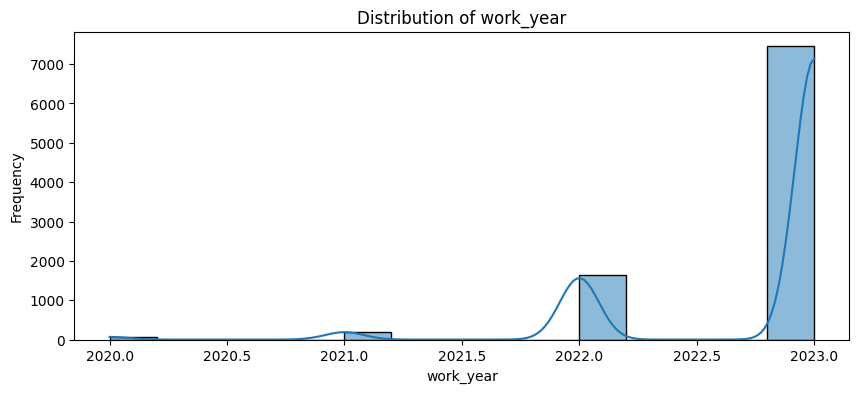

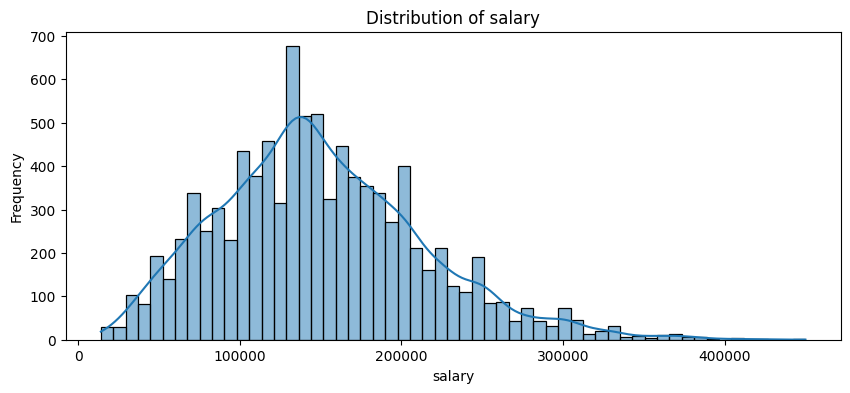

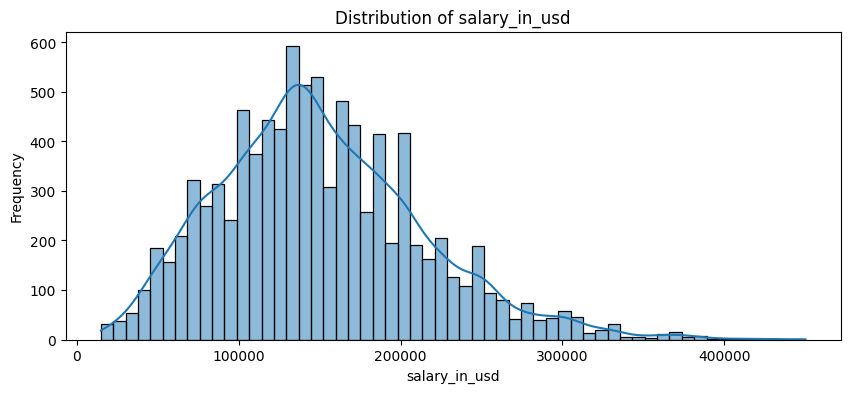

In [14]:
# Draw caster for numerical columns
numerical_cols = df.select_dtypes(include='number').columns
for col in numerical_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

- Vẽ pair plot cho các trường numeric

Giải thích các thành phần trong pair plot:

- Diagonal: Biểu đồ histogram cho từng cột số, giúp ta thấy phân phối dữ liệu.
- Off-diagonal: Biểu đồ scatter giữa các cặp cột số, giúp ta thấy mối quan hệ giữa chúng (nếu có). Nếu có xu hướng tuyến tính, cụm, hoặc mối quan hệ phi tuyến, sẽ hiển thị rõ ràng ở đây.

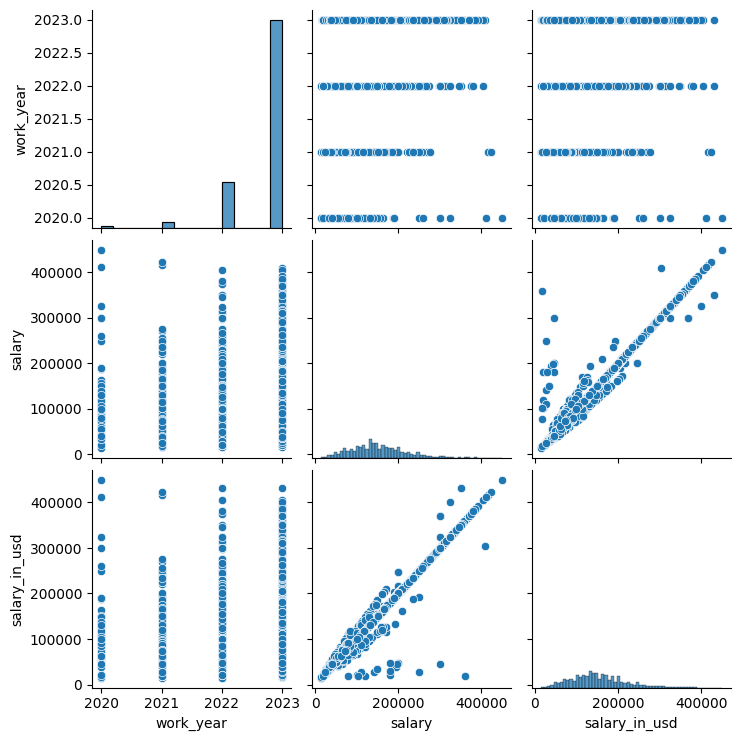

In [15]:
# scatter plot for numerical columns in seperate frame
sns.pairplot(df.select_dtypes(include='number').dropna())
